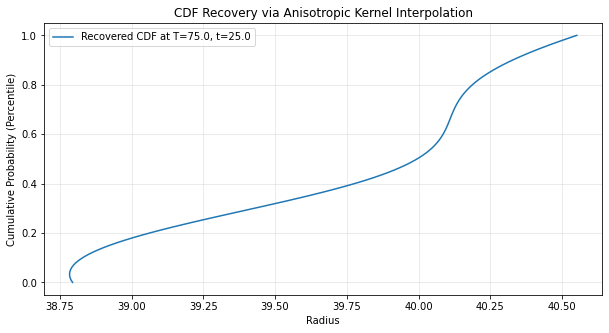

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
# Inputs: (Initial Temp, Time, Percentile) -> Output: Radius
np.random.seed(42)
n_samples = 200

# Features: T_init (0-100), Time (0-10), Percentile (0-1)
X = np.column_stack([
    np.random.uniform(20, 100, n_samples),  # Temp
    np.random.uniform(0, 50, n_samples),    # Time
    np.random.uniform(0, 1, n_samples)      # Percentile
])

# Target: A dummy physics-inspired function
# Radius grows with sqrt(time), scales with temp, and uses Percentile for CDF spread
def true_radius_func(X):
    temp, time, p = X[:, 0], X[:, 1], X[:, 2]
    return (0.1 * temp) * np.sqrt(time) + (p * 5) 

y = true_radius_func(X) + np.random.normal(0, 0.5, n_samples)

# 2. Define the Anisotropic Gaussian Kernel
def anisotropic_gaussian_kernel(x1, x2, length_scales):
    """
    Computes K(x1, x2) = exp(-0.5 * sum(( (x1-x2) / length_scales )^2 ))
    length_scales: array-like [l_temp, l_time, l_percentile]
    """
    dists = ((x1 - x2) / length_scales)**2
    return np.exp(-0.5 * np.sum(dists))

# 3. Kernel Regression Solver (Nadaraya-Watson)
class AnisotropicKernelRegressor:
    def __init__(self, length_scales):
        self.length_scales = np.array(length_scales)
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X_test):
        y_pred = []
        for x_q in X_test:
            # Calculate weights for all training points relative to query point x_q
            # Vectorized distance calculation
            diffs = (self.X_train - x_q) / self.length_scales
            weights = np.exp(-0.5 * np.sum(diffs**2, axis=1))
            
            # Weighted average
            sum_weights = np.sum(weights)
            if sum_weights == 0:
                y_pred.append(np.mean(self.y_train))
            else:
                y_pred.append(np.sum(weights * self.y_train) / sum_weights)
        return np.array(y_pred)

# 4. Fitting and Interpolation
# Length scales determine the "smoothness" in each dimension
# Large value = smoother/less sensitive; Small value = high sensitivity
l_scales = [15.0, 10.0, 0.2] # Temp, Time, Percentile
model = AnisotropicKernelRegressor(length_scales=l_scales)
model.fit(X, y)

# 5. Recovering the CDF for a specific (Temp, Time)
T_fixed = 75.0
t_fixed = 25.0
p_range = np.linspace(0, 1, 100)

# Create test points: holding T and t constant, varying p
X_query = np.column_stack([
    np.full(100, T_fixed),
    np.full(100, t_fixed),
    p_range
])

predicted_radii = model.predict(X_query)

# 6. Visualization
plt.figure(figsize=(10, 5))
plt.plot(predicted_radii, p_range, label=f'Recovered CDF at T={T_fixed}, t={t_fixed}')
plt.xlabel('Radius')
plt.ylabel('Cumulative Probability (Percentile)')
plt.title('CDF Recovery via Anisotropic Kernel Interpolation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()